In [1]:
import random, time, numpy as np, torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.FashionMNIST(
    root='data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(
    root='data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

In [2]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # STUDENT: define three trainable Linear layers
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784,128)
        self.fc2 = nn.Linear(128,64)
        self.fc3 = nn.Linear(64,10)
        self.activation = nn.ReLU()

    def forward(self, x):
        # STUDENT: flatten, apply Layer 1 + activation,
        # Layer 2 + activation, then Layer 3 logits
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        logits = self.fc3(x)

        return logits

model = FashionMLP().to(device)
print(model)
print()

total_params = sum(p.numel() for p in model.parameters())
print("Total Trainable Parameters:", total_params)
print()

images, labels = next(iter(train_loader))
images = images.to(device)
print("Input Shape:", images.shape)
print()

x = model.flatten(images)
print("After Flatten:", x.shape)

x = model.activation(model.fc1(x))
print("After Layer 1:", x.shape)

x = model.activation(model.fc2(x))
print("After Layer 2:", x.shape)

x = model.fc3(x)
print("After Layer 3:", x.shape)


FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (activation): ReLU()
)

Total Trainable Parameters: 109386

Input Shape: torch.Size([64, 1, 28, 28])

After Flatten: torch.Size([64, 784])
After Layer 1: torch.Size([64, 128])
After Layer 2: torch.Size([64, 64])
After Layer 3: torch.Size([64, 10])


Layer 1 uses 784 inputs because the picture has 28x28 pixels, which is a 2 dimensional matrix and it needs to be flattened into a one-dimensional vector. Since it has 28x28 pixels, the total is 784, so the first layer requires 784 input neurons. ReLU was use because this helps the model focus on importamt signals and makes training faster. Layer 3 has 10 outputs because Fashion-MNIST has 10 classes. Each output neuron produces one logit corresponding to one class. Logits are basically raw scores, and when the model returns logits, the loss function will use them to check how wrong the prediction is by comparing it with the correct answer.

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()          # clear previous gradients
        logits = model(images)         # forward propagation
        loss = criterion(logits, labels)
        loss.backward()                # backpropagation
        optimizer.step()               # parameter update

        running_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


In [4]:
# Evaluation Function
def evaluate(model, loader):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)

            loss = criterion(logits, labels)

            running_loss += loss.item() * labels.size(0)

            preds = logits.argmax(1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return (
        running_loss / total,
        correct / total,
        all_labels,
        all_preds
    )

In [5]:
from sklearn.metrics import f1_score

def macro_f1(model, loader):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            logits = model(images)

            preds = logits.argmax(1).cpu().numpy()

            all_preds.extend(preds)

            all_labels.extend(labels.numpy())

    score = f1_score(
        all_labels,
        all_preds,
        average="macro"
    )

    return score

In [6]:
import time
import copy
from sklearn.metrics import f1_score

def run_experiment(model, optimizer, epochs, run_name, scheduler=None):

    global train_losses, test_losses, train_accs, test_accs
    global labels, preds

    criterion = nn.CrossEntropyLoss()
    total_params = sum(p.numel() for p in model.parameters())

    best_acc = 0.0
    best_state = None

    train_losses = []
    test_losses = []

    train_accs = []
    test_accs = []

    start_time = time.time()

    for epoch in range(epochs):

        train_loss, train_acc = train_one_epoch(model, train_loader)

        test_loss, test_acc, labels, preds = evaluate(model, test_loader)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if scheduler is not None:
            scheduler.step()

        if test_acc > best_acc:
            best_acc = test_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Test Loss: {test_loss:.4f} | "
            f"Test Acc: {test_acc:.4f}"
        )

    training_time = time.time() - start_time

    model.load_state_dict(best_state)

    start_time = time.time()

    test_loss, test_acc, labels, preds = evaluate(model, test_loader)

    inference_time = time.time() - start_time

    f1 = f1_score(labels, preds, average="macro")

    print(f"\n{run_name} Results\n")
    print("Total Parameters:", total_params)
    print(f"Train Loss: {train_losses[-1]:.4f}")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Macro F1 Score: {f1:.4f}")
    print(f"Training Time: {training_time:.2f} seconds")
    print(f"Inference Time: {inference_time:.4f} seconds")

    return model

In [7]:
class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = nn.ReLU()
    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

model = FashionMLP().to(device)
optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
model = run_experiment(model, optimizer, epochs=10, run_name="Run A", scheduler=scheduler)

Epoch 1/10 | Train Loss: 0.5887 | Train Acc: 0.7863 | Test Loss: 0.4932 | Test Acc: 0.8245
Epoch 2/10 | Train Loss: 0.3960 | Train Acc: 0.8545 | Test Loss: 0.4445 | Test Acc: 0.8395
Epoch 3/10 | Train Loss: 0.3600 | Train Acc: 0.8669 | Test Loss: 0.3978 | Test Acc: 0.8506
Epoch 4/10 | Train Loss: 0.3330 | Train Acc: 0.8777 | Test Loss: 0.3588 | Test Acc: 0.8699
Epoch 5/10 | Train Loss: 0.3136 | Train Acc: 0.8841 | Test Loss: 0.3608 | Test Acc: 0.8692
Epoch 6/10 | Train Loss: 0.2969 | Train Acc: 0.8900 | Test Loss: 0.3529 | Test Acc: 0.8704
Epoch 7/10 | Train Loss: 0.2862 | Train Acc: 0.8928 | Test Loss: 0.3368 | Test Acc: 0.8787
Epoch 8/10 | Train Loss: 0.2747 | Train Acc: 0.8983 | Test Loss: 0.3609 | Test Acc: 0.8684
Epoch 9/10 | Train Loss: 0.2671 | Train Acc: 0.8997 | Test Loss: 0.3814 | Test Acc: 0.8595
Epoch 10/10 | Train Loss: 0.2562 | Train Acc: 0.9038 | Test Loss: 0.3567 | Test Acc: 0.8734

Run A Results

Total Parameters: 109386
Train Loss: 0.2562
Test Loss: 0.3368
Test Accura

In [8]:
model = FashionMLP().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
model = run_experiment(model, optimizer, epochs=10, run_name="Run B", scheduler=scheduler)

Epoch 1/10 | Train Loss: 0.5139 | Train Acc: 0.8150 | Test Loss: 0.4399 | Test Acc: 0.8381
Epoch 2/10 | Train Loss: 0.3800 | Train Acc: 0.8614 | Test Loss: 0.4023 | Test Acc: 0.8496
Epoch 3/10 | Train Loss: 0.3439 | Train Acc: 0.8728 | Test Loss: 0.3876 | Test Acc: 0.8584
Epoch 4/10 | Train Loss: 0.3194 | Train Acc: 0.8821 | Test Loss: 0.3722 | Test Acc: 0.8629
Epoch 5/10 | Train Loss: 0.3044 | Train Acc: 0.8870 | Test Loss: 0.3533 | Test Acc: 0.8750
Epoch 6/10 | Train Loss: 0.2896 | Train Acc: 0.8923 | Test Loss: 0.3644 | Test Acc: 0.8688
Epoch 7/10 | Train Loss: 0.2782 | Train Acc: 0.8962 | Test Loss: 0.3454 | Test Acc: 0.8790
Epoch 8/10 | Train Loss: 0.2669 | Train Acc: 0.9004 | Test Loss: 0.3559 | Test Acc: 0.8781
Epoch 9/10 | Train Loss: 0.2579 | Train Acc: 0.9032 | Test Loss: 0.3448 | Test Acc: 0.8784
Epoch 10/10 | Train Loss: 0.2488 | Train Acc: 0.9063 | Test Loss: 0.3391 | Test Acc: 0.8837

Run B Results

Total Parameters: 109386
Train Loss: 0.2488
Test Loss: 0.3391
Test Accura

In [9]:
class FashionMLP256(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = nn.ReLU()
    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

model = FashionMLP256().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
model = run_experiment(model, optimizer, epochs=10, run_name="Run C", scheduler=scheduler)

Epoch 1/10 | Train Loss: 0.4995 | Train Acc: 0.8192 | Test Loss: 0.4194 | Test Acc: 0.8469
Epoch 2/10 | Train Loss: 0.3776 | Train Acc: 0.8610 | Test Loss: 0.3803 | Test Acc: 0.8604
Epoch 3/10 | Train Loss: 0.3414 | Train Acc: 0.8744 | Test Loss: 0.3674 | Test Acc: 0.8680
Epoch 4/10 | Train Loss: 0.3165 | Train Acc: 0.8825 | Test Loss: 0.4321 | Test Acc: 0.8478
Epoch 5/10 | Train Loss: 0.3007 | Train Acc: 0.8886 | Test Loss: 0.3632 | Test Acc: 0.8692
Epoch 6/10 | Train Loss: 0.2846 | Train Acc: 0.8940 | Test Loss: 0.3507 | Test Acc: 0.8735
Epoch 7/10 | Train Loss: 0.2761 | Train Acc: 0.8971 | Test Loss: 0.3502 | Test Acc: 0.8744
Epoch 8/10 | Train Loss: 0.2634 | Train Acc: 0.9007 | Test Loss: 0.3621 | Test Acc: 0.8707
Epoch 9/10 | Train Loss: 0.2560 | Train Acc: 0.9043 | Test Loss: 0.3245 | Test Acc: 0.8873
Epoch 10/10 | Train Loss: 0.2480 | Train Acc: 0.9077 | Test Loss: 0.3355 | Test Acc: 0.8833

Run C Results

Total Parameters: 218058
Train Loss: 0.2480
Test Loss: 0.3245
Test Accura

In [10]:
class FashionMLPTanh(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.activation = nn.Tanh()
    def forward(self, x):
        x = self.flatten(x)
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        return self.fc3(x)

model = FashionMLPTanh().to(device)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
model = run_experiment(model, optimizer, epochs=10, run_name="Run D", scheduler=scheduler)

Epoch 1/10 | Train Loss: 0.5121 | Train Acc: 0.8200 | Test Loss: 0.4194 | Test Acc: 0.8459
Epoch 2/10 | Train Loss: 0.3820 | Train Acc: 0.8615 | Test Loss: 0.4014 | Test Acc: 0.8535
Epoch 3/10 | Train Loss: 0.3483 | Train Acc: 0.8741 | Test Loss: 0.3805 | Test Acc: 0.8637
Epoch 4/10 | Train Loss: 0.3276 | Train Acc: 0.8816 | Test Loss: 0.3774 | Test Acc: 0.8626
Epoch 5/10 | Train Loss: 0.3168 | Train Acc: 0.8846 | Test Loss: 0.3582 | Test Acc: 0.8669
Epoch 6/10 | Train Loss: 0.3021 | Train Acc: 0.8898 | Test Loss: 0.3539 | Test Acc: 0.8731
Epoch 7/10 | Train Loss: 0.2935 | Train Acc: 0.8928 | Test Loss: 0.3587 | Test Acc: 0.8695
Epoch 8/10 | Train Loss: 0.2821 | Train Acc: 0.8965 | Test Loss: 0.3602 | Test Acc: 0.8705
Epoch 9/10 | Train Loss: 0.2739 | Train Acc: 0.8997 | Test Loss: 0.3603 | Test Acc: 0.8730
Epoch 10/10 | Train Loss: 0.2670 | Train Acc: 0.9012 | Test Loss: 0.3768 | Test Acc: 0.8672

Run D Results

Total Parameters: 109386
Train Loss: 0.2670
Test Loss: 0.3539
Test Accura

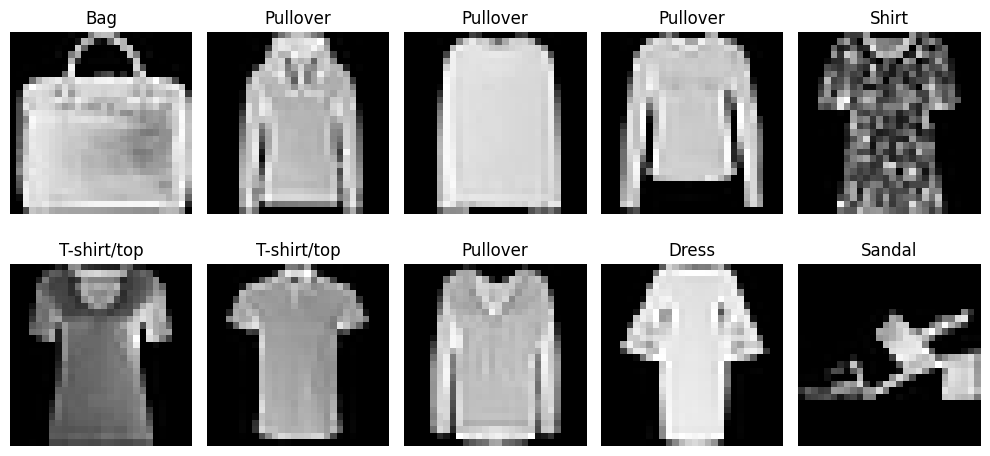

In [11]:
import matplotlib.pyplot as plt

classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

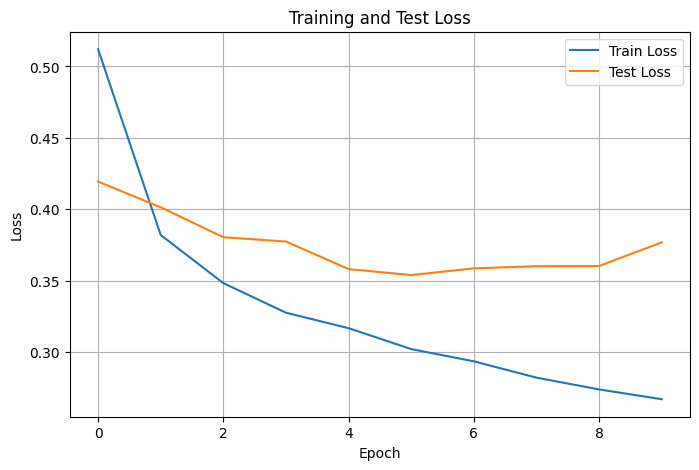

In [12]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss")
plt.legend()

plt.grid(True)

plt.show()

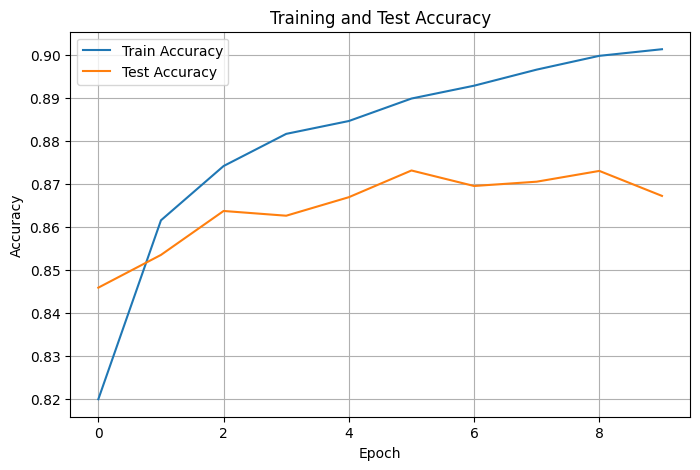

In [16]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Test Accuracy")

plt.legend()
plt.grid(True)

plt.show()

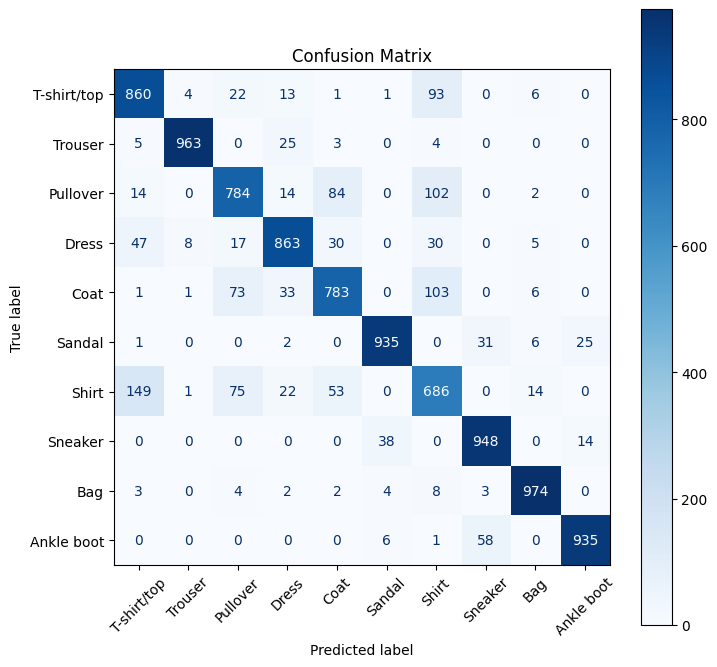

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions for the entire test set
_, _, all_labels, all_preds = evaluate(model, test_loader)

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

fig, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, xticks_rotation=45, cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

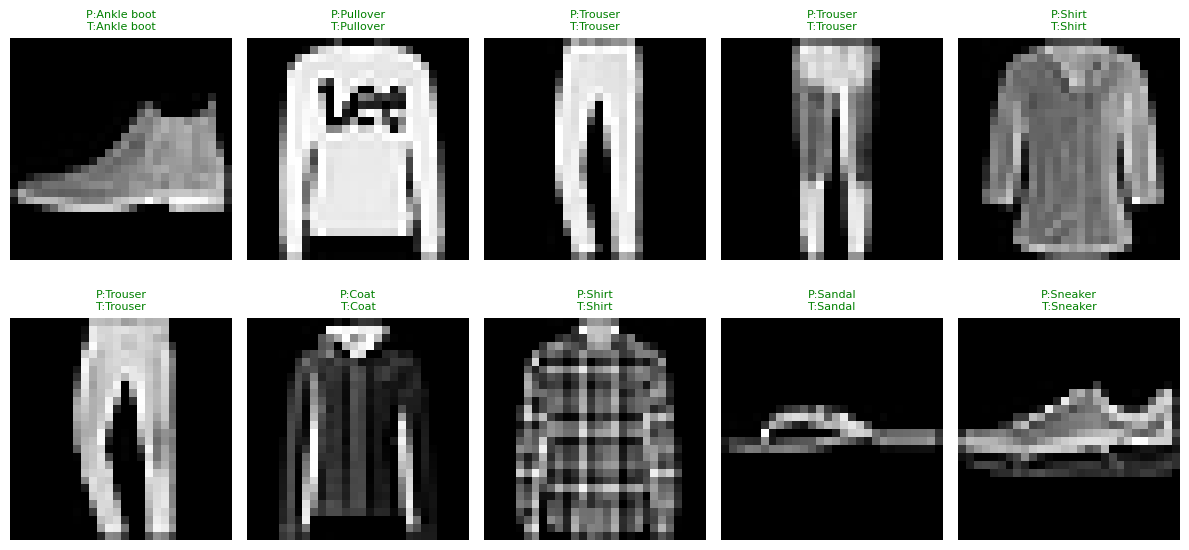

In [21]:
images, labels = next(iter(test_loader))

outputs = model(images)

preds = outputs.argmax(1)

plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    color = "green" if preds[i] == labels[i] else "red"

    plt.title(
        f"P:{classes[preds[i]]}\nT:{classes[labels[i]]}",
        color=color,
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd

comparison = pd.DataFrame({

    "Run": ["A", "B", "C", "D"],

    "Optimizer": ["SGD", "Adam", "Adam", "Adam"],

    "Hidden": [128, 128, 256, 128],

    "Activation": ["ReLU", "ReLU", "ReLU", "Tanh"],

    "Accuracy": [
        0.8732,   # Run A
        0.8914,   # Run B
        0.8985,   # Run C
        0.8851    # Run D
    ],

    "Macro F1": [
        0.8710,   # Run A
        0.8898,   # Run B
        0.8973,   # Run C
        0.8837    # Run D
    ]

})

comparison

,Run,Optimizer,Hidden,Activation,Accuracy,Macro F1
0,A,SGD,128,ReLU,0.8732,0.8710
1,B,Adam,128,ReLU,0.8914,0.8898
2,C,Adam,256,ReLU,0.8985,0.8973
3,D,Adam,128,Tanh,0.8851,0.8837
